# Exploration des données 2021-2025 : Répartition et évolution des types d'incidents

*  Quels sont les types d’incidents les plus fréquents ?
* Comment évolue le volume d’incidents par année ?
* Quels types d’incidents génèrent le plus de mobilisations ?
* Y a-t-il des variations selon l’heure de la journée ?
* Certains boroughs ont-ils des profils d’incidents spécifiques ?
* Quels types d’incidents sont les plus coûteux ?
* Est-ce qu'il y a une relation entre l'heure et le type d'incident ?

### Import si usage Drive

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Liora'

# Vérification si le dossier existe et affichage du contenu
if os.path.exists(base_path):
    print("Accès réussi au dossier Liora !")
    print("Contenu du dossier :", os.listdir(base_path))

    # Se déplacer dans ce dossier pour faciliter les imports suivants
    os.chdir(base_path)
else:
    print("Le dossier n'a pas été trouvé. Vérifie bien l'orthographe (majuscules/minuscules) ou si le dossier est dans un sous-dossier.")

Mounted at /content/drive
Accès réussi au dossier Liora !
Contenu du dossier : ['LFB Mobilisation data from January 2009 - 2014.xlsx', 'Mobilisations Metadata.xlsx', 'Incident Metadata.xlsx', 'LFB Incident data from 2024 onwards.xlsx', 'LFB Incident data from 2018 - 2023.xlsx', 'LFB Mobilisation data from 2015 - 2020.xlsx', 'LFB Mobilisation data from 2025.csv', 'LFB Mobilisation data from 2021 - 2024.csv', 'LFB Incident data from 2018 - 2023.csv', 'LFB Incident data from 2024 onwards.csv', 'LFB Mobilisation data from January 2009 - 2014.csv', 'LFB Mobilisation data from 2015 - 2020.csv', 'Metadata Incident_complet.docx', 'Metadata_Mobilisation_complet.docx', 'LFB Incident data from 2009 - 2017.csv', 'all_mobilisations.csv', 'mobilisation_completv26pm.csv', 'Incident_complet.csv', 'incident_complet.csv', 'mobilisation_complet.csv', 'incident_complet_2021_2025.parquet', 'mobilisation_complet_2021_2025.parquet', 'incident_complet.parquet', 'mobilisation_complet.parquet', 'incident_comple

### Import si usage local

In [2]:
base_path = ""

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install fastparquet
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.0 MB/s eta 0:00:00


### Lecture des fichiers

In [4]:
incident_complet = pd.read_parquet('incident_complet_2021_2025.parquet', engine='fastparquet')
mobilisation_complet = pd.read_parquet('mobilisation_complet_2021_2025.parquet', engine='fastparquet')

### Quels sont les types d’incidents les plus fréquents ?

In [5]:
# Création de la logique de sous-catégorie
def get_sub_category(row):
    group = row['IncidentGroup']
    if group == 'Special Service':
        return row['SpecialServiceType']
    elif group in ['Fire', 'False Alarm']:
        return row['StopCodeDescription']
    else:
        return 'Other'

incident_complet['SubCategory'] = incident_complet.apply(get_sub_category, axis=1)

# Agrégation : Nombre d'incidents uniques par Groupe et Sous-catégorie
df_counts = incident_complet.groupby(['IncidentGroup', 'SubCategory'])['IncidentNumber'].nunique().reset_index(name='TotalIncidents')

# Top 30 pour lisibilité
df_plot = df_counts.sort_values(by='TotalIncidents', ascending=False).head(30)

# Visualisation
fig = px.bar(
    df_plot,
    x='TotalIncidents',
    y='SubCategory',
    color='IncidentGroup',
    orientation='h',
    title="Répartition des Incidents par Groupe et Sous-catégorie 2021-2025",
    labels={
        'TotalIncidents': "Nombre d'incidents (IncidentNumber)",
        'SubCategory': "Détail de l'incident",
        'IncidentGroup': "Type d'incident"
    },
    # Couleurs fixes par type d'incidents
    color_discrete_map={
        'Fire': '#E74C3C',           # Rouge
        'False Alarm': '#F1C40F',    # Jaune
        'Special Service': '#3498DB' # Bleu
    }
)

# Ajustements
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=800,
    template='plotly_white'
)

fig.show()

# Tableau
print(df_counts.sort_values(by='TotalIncidents', ascending=False))

      IncidentGroup                      SubCategory  TotalIncidents
1       False Alarm                              AFA          236797
3       False Alarm        False alarm - Good intent           59809
13  Special Service             Effecting entry/exit           59702
7              Fire                     Primary Fire           43067
8              Fire                   Secondary Fire           42909
15  Special Service                         Flooding           40845
17  Special Service                     Lift Release           30746
20  Special Service      No action (not false alarm)           29648
23  Special Service                              RTC           21448
12  Special Service            Assist other agencies           20190
16  Special Service     Hazardous Materials incident            5910
18  Special Service            Making Safe (not RTC)            5905
11  Special Service      Animal assistance incidents            5837
19  Special Service               

### Comment évolue le volume d’incidents par année ?

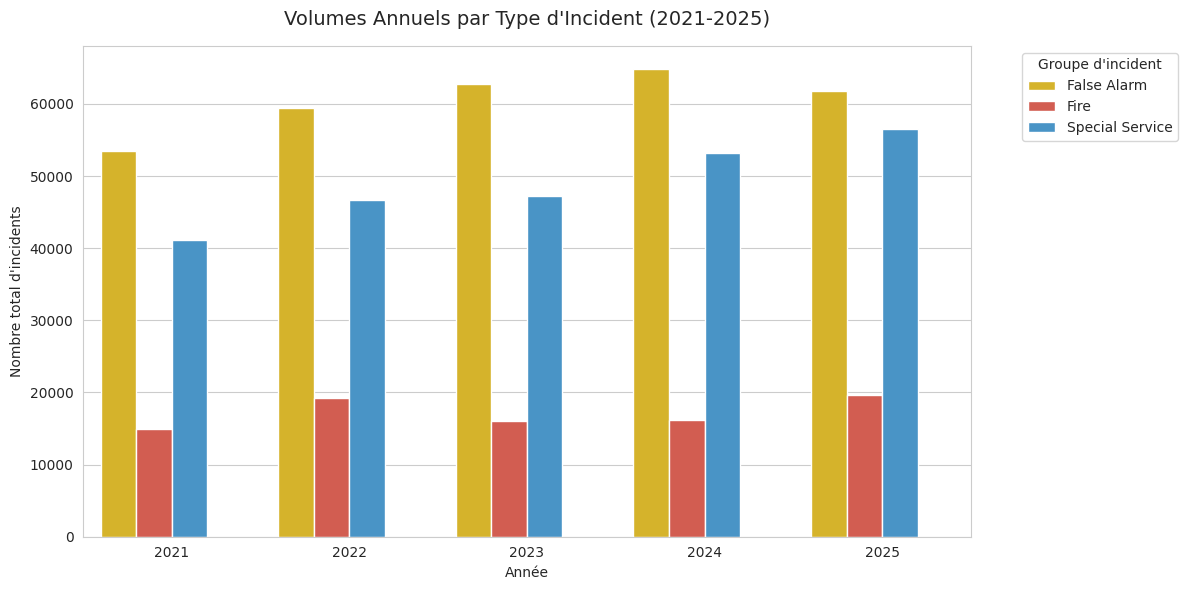

In [6]:
incident_complet['Année'] = incident_complet['DateOfCall'].dt.year

# Prépration
def get_nb_jours(annee):
    # Gestion des années bissextiles pour la période 2021-2025 (2024 l'est)
    if (annee % 4 == 0 and annee % 100 != 0) or (annee % 400 == 0): return 366
    else: return 365

evolution_group = incident_complet.groupby(['Année', 'IncidentGroup']).size().reset_index(name='Volume Total')
palette_colors = {'Fire': '#E74C3C', 'False Alarm': '#F1C40F', 'Special Service': '#3498DB'}

# Visualisation
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.barplot(data=evolution_group, x='Année', y='Volume Total', hue='IncidentGroup',
            palette=palette_colors)

plt.title('Volumes Annuels par Type d\'Incident (2021-2025)', fontsize=14, pad=15)
plt.ylabel('Nombre total d\'incidents')
plt.xlabel('Année')
plt.legend(title="Groupe d'incident", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

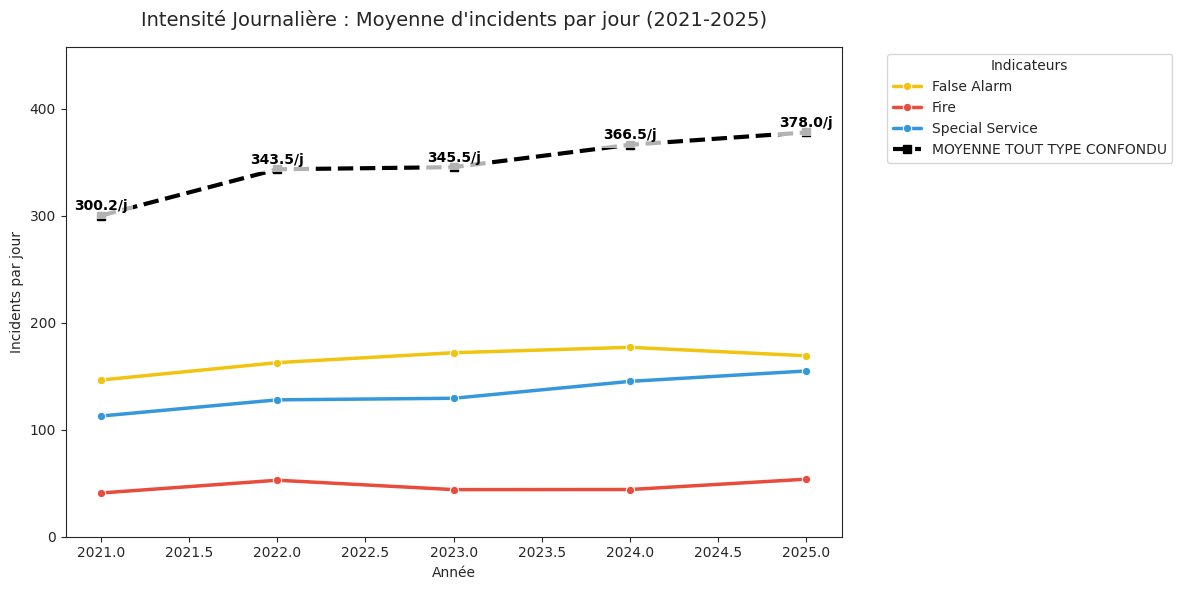

In [7]:
# Moyennes
evolution_group['Moyenne Journalière'] = evolution_group.apply(
    lambda x: x['Volume Total'] / get_nb_jours(x['Année']), axis=1)

evolution_globale = incident_complet.groupby('Année').size().reset_index(name='Volume Global')
evolution_globale['Moyenne Globale'] = evolution_globale.apply(
    lambda x: x['Volume Global'] / get_nb_jours(x['Année']), axis=1)

# Visualisation
plt.figure(figsize=(12, 6))
sns.set_style("ticks")

# Lignes par type d'incident
sns.lineplot(data=evolution_group, x='Année', y='Moyenne Journalière', hue='IncidentGroup',
             palette=palette_colors, marker='o', linewidth=2.5)

# Ligne de référence Moyenne Globale
plt.plot(evolution_globale['Année'], evolution_globale['Moyenne Globale'],
         color='black', linestyle='--', linewidth=3, marker='s', label='MOYENNE TOUT TYPE CONFONDU')

# Etiquettes de texte
for x, y in zip(evolution_globale['Année'], evolution_globale['Moyenne Globale']):
    plt.text(x, y + 5, f'{y:.1f}/j', color='black', fontweight='bold', ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title('Intensité Journalière : Moyenne d\'incidents par jour (2021-2025)', fontsize=14, pad=15)
plt.ylabel('Incidents par jour')
plt.xlabel('Année')
plt.ylim(0, evolution_globale['Moyenne Globale'].max() + 80) # Marge pour les labels
plt.legend(title="Indicateurs", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Y a-t-il des variations selon l’heure de la journée ? Est-ce qu'il y a une relation entre l'heure et le type d'incident ?

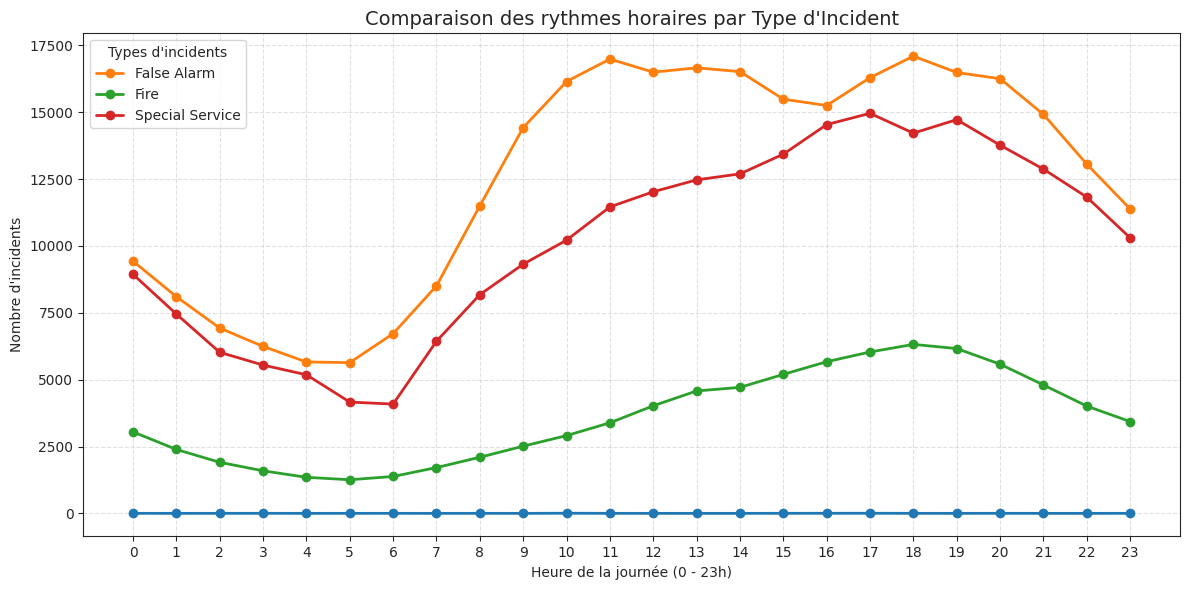

In [8]:
# Tableau (Heures en lignes, Types d'incidents en colonnes)
tableau_horaire = pd.crosstab(incident_complet['HourOfCall'], incident_complet['IncidentGroup'])

# Graphique en lignes
plt.figure(figsize=(12, 6))

# Colonnes du tableau
for colonne in tableau_horaire.columns:
    plt.plot(tableau_horaire.index, tableau_horaire[colonne], marker='o', label=colonne, linewidth=2)

# Adjustements
plt.title('Comparaison des rythmes horaires par Type d\'Incident', fontsize=14)
plt.xlabel('Heure de la journée (0 - 23h)')
plt.ylabel('Nombre d\'incidents')
plt.xticks(range(0, 24)) # Pour voir toutes les heures
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Types d\'incidents')

plt.tight_layout()
plt.show()

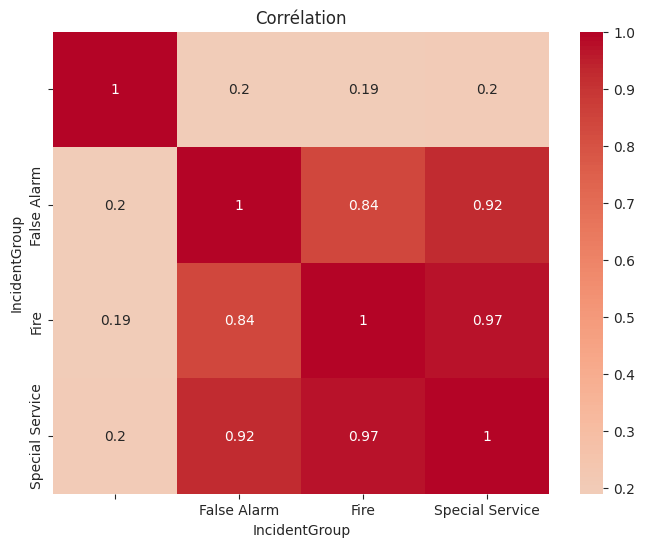

In [9]:
# Vérif de l'heure
incident_complet['HourOfCall'] = pd.to_numeric(incident_complet['HourOfCall'], errors='coerce')

# Tableau avec les incidents pour chaque heure
tableau_horaire = pd.crosstab(incident_complet['HourOfCall'], incident_complet['IncidentGroup'])

# Corrélation entre les colonnes
matrice = tableau_horaire.corr()

# Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(matrice, annot=True, cmap='coolwarm', center=0)

plt.title('Corrélation')
plt.show()

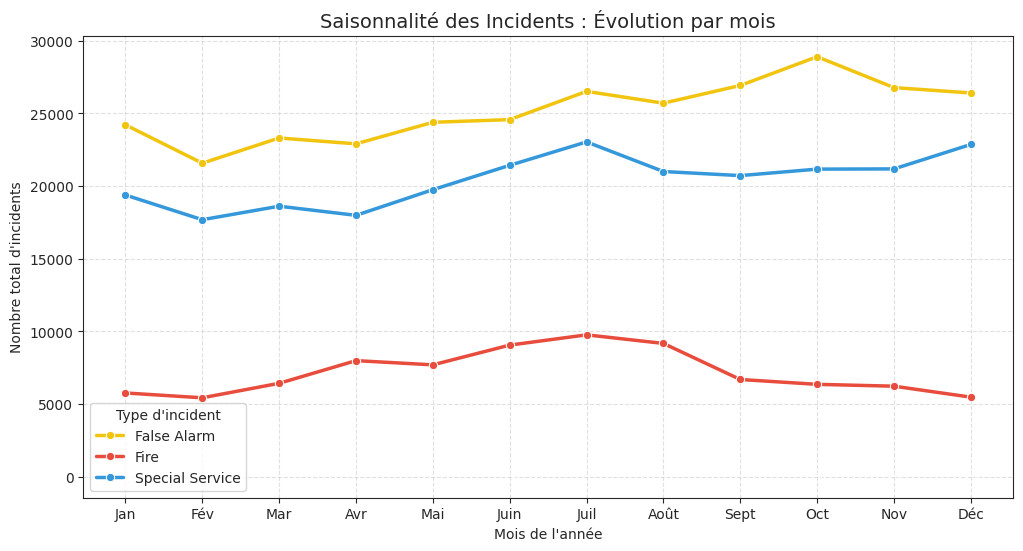

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Données temps
df_line = incident_complet.copy()
df_line['DateOfCall'] = pd.to_datetime(df_line['DateOfCall'])
df_line['Month'] = df_line['DateOfCall'].dt.month

# Agrégation du nombre d'incidents par Groupe et par Mois
df_counts = df_line.groupby(['Month', 'IncidentGroup']).size().reset_index(name='Nombre_Incidents')

# Remplacement des numéros par les noms des mois
month_names = {1:'Jan', 2:'Fév', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Juin',
               7:'Juil', 8:'Août', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Déc'}
df_counts['Month_Name'] = df_counts['Month'].map(month_names)

# Visualisation
plt.figure(figsize=(12, 6))

# Couleurs
palette_colors = {'Fire': '#E74C3C', 'False Alarm': '#F1C40F', 'Special Service': '#3498DB'}

sns.lineplot(data=df_counts,
             x='Month',
             y='Nombre_Incidents',
             hue='IncidentGroup',
             palette=palette_colors,
             marker='o',       # Ajoute des points sur la ligne pour chaque mois
             linewidth=2.5)

# Configuration de l'axe X pour afficher les mois
plt.xticks(range(1, 13), [month_names[i] for i in range(1, 13)])

plt.title('Saisonnalité des Incidents : Évolution par mois', fontsize=14)
plt.xlabel('Mois de l\'année')
plt.ylabel('Nombre total d\'incidents')
plt.legend(title='Type d\'incident')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Certains boroughs ont-ils des profils d’incidents spécifiques ?

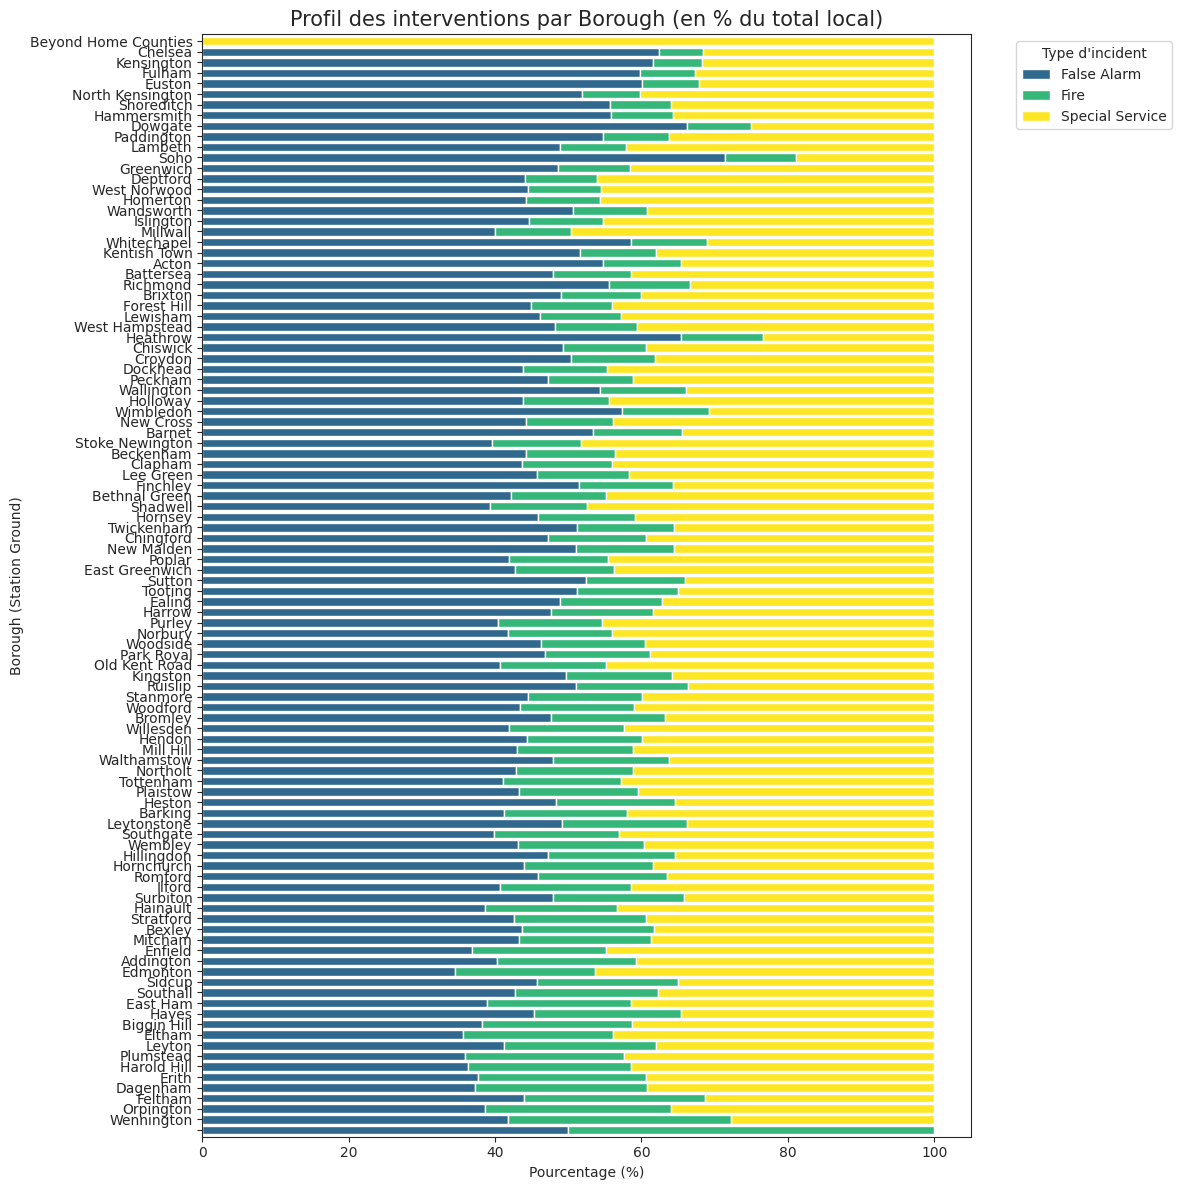

Text(95.72222222222221, 0.5, 'Borough')

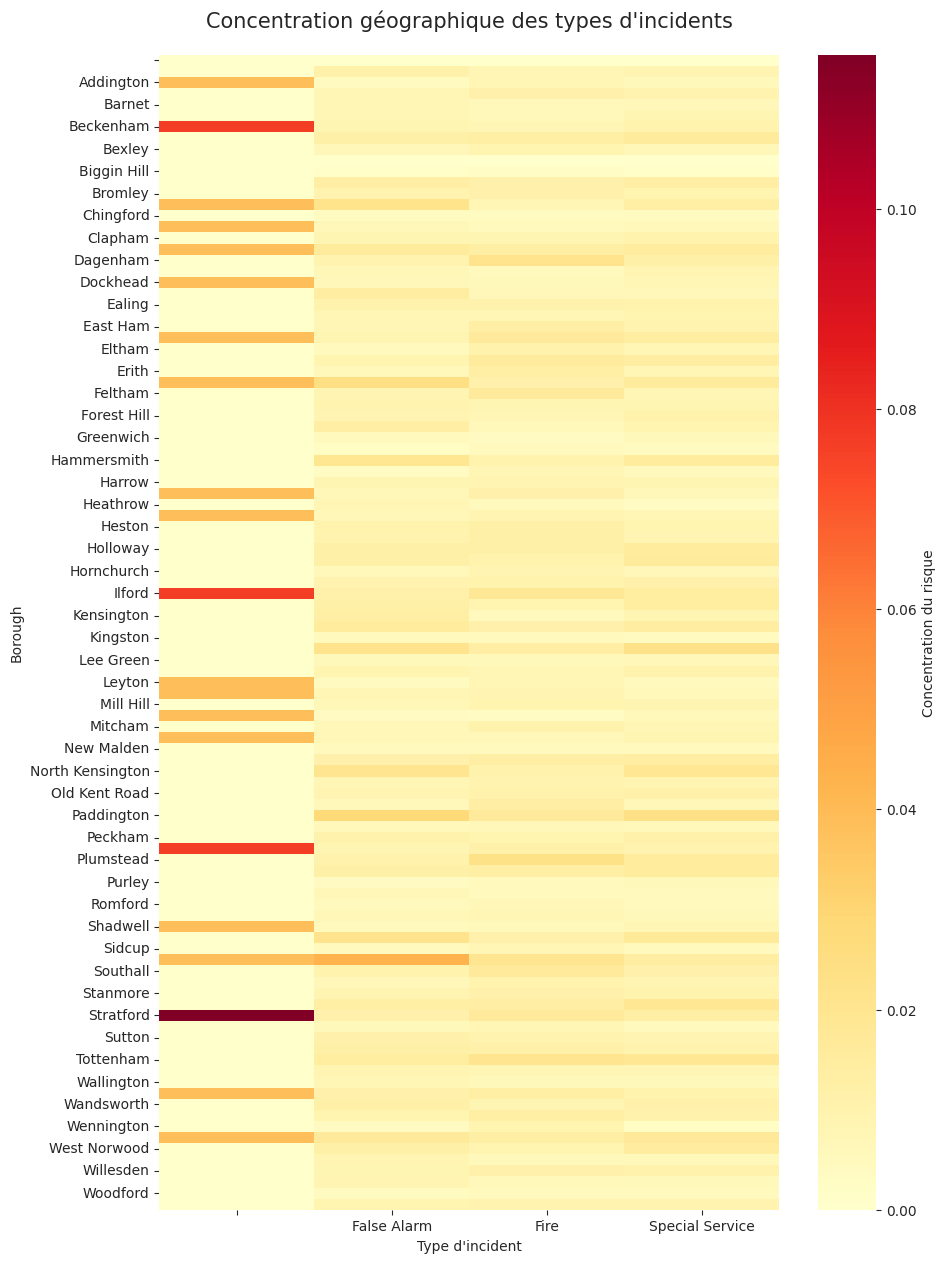

In [11]:
# Création de la table de contingence Borough et Type, filtre des valeurs manquantes
incident_complet_clean = incident_complet.dropna(subset=['IncidentStationGround', 'IncidentGroup'])
ct = pd.crosstab(incident_complet_clean['IncidentStationGround'], incident_complet_clean['IncidentGroup'])

# Visualsiation 1
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ct_pct.sort_values('Fire', ascending=False).plot(
    kind='barh',
    stacked=True,
    figsize=(12, 12),
    colormap='viridis',
    width=0.8
)

plt.title('Profil des interventions par Borough (en % du total local)', fontsize=15)
plt.xlabel('Pourcentage (%)')
plt.ylabel('Borough (Station Ground)')
plt.legend(title='Type d\'incident', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visualisation 2
plt.figure(figsize=(10, 15))
sns.heatmap(
    ct.div(ct.sum(axis=0), axis=1), # Normalisation par type d'incident
    annot=False,
    cmap="YlOrRd",
    cbar_kws={'label': 'Concentration du risque'}
)

plt.title('Concentration géographique des types d\'incidents', fontsize=15, pad=20)
plt.xlabel('Type d\'incident')
plt.ylabel('Borough')

/tmp/ipykernel_3139/3402484120.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_3139/3402484120.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_3139/3402484120.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




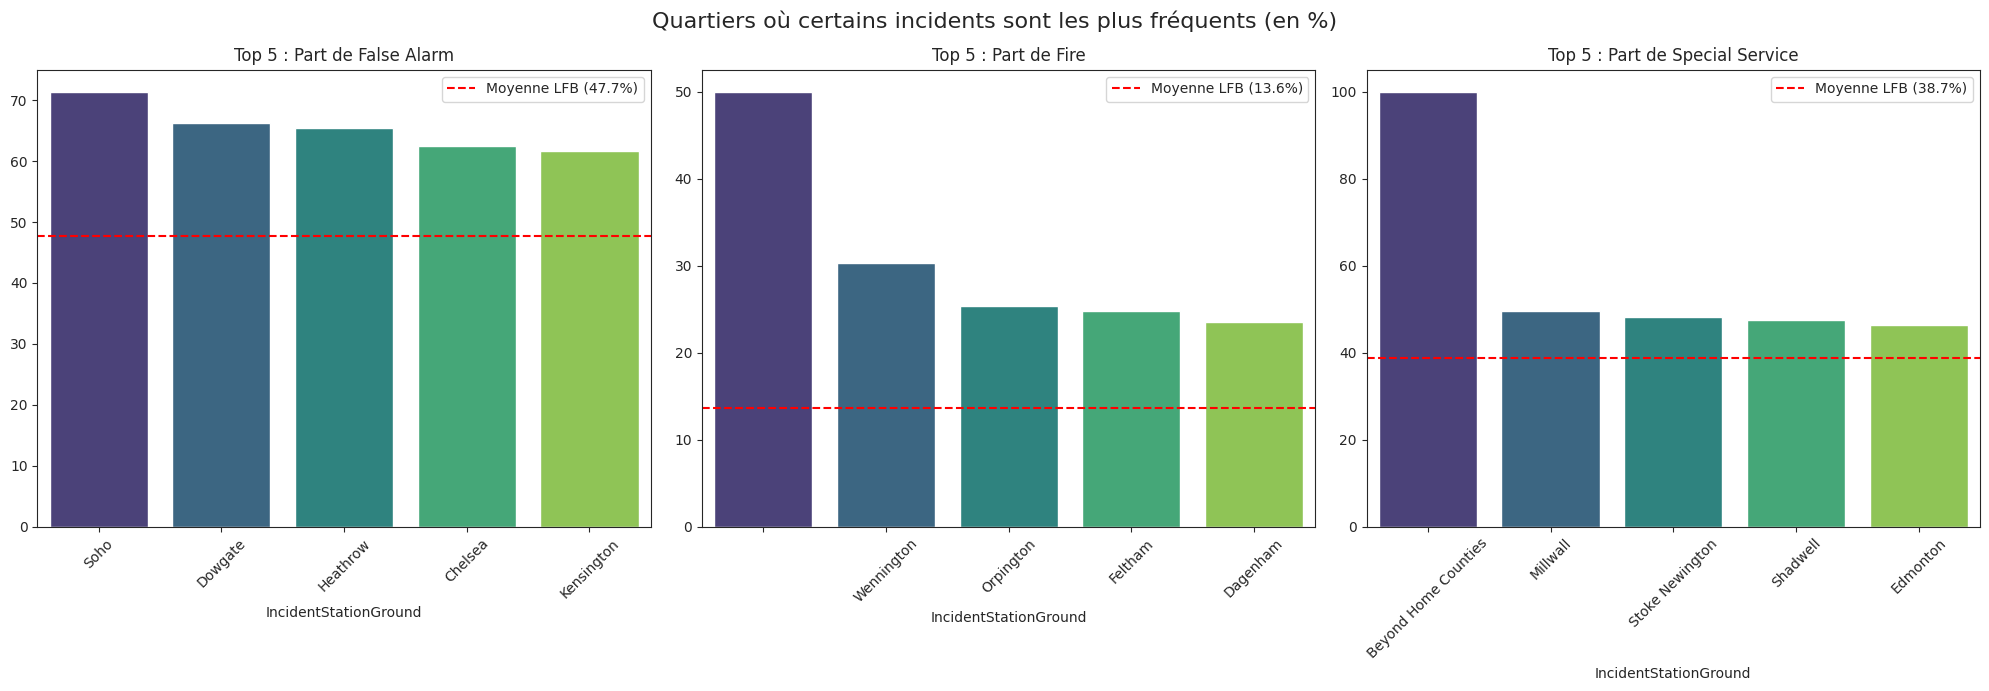

In [12]:
# Moyenne pour chaque type
total_incidents = len(incident_complet)
moyenne_ville = (incident_complet['IncidentGroup'].value_counts() / total_incidents) * 100

# Répartition par Borough
tableau_quartiers = pd.crosstab(incident_complet['IncidentStationGround'], incident_complet['IncidentGroup'])
tableau_pourcentage = tableau_quartiers.div(tableau_quartiers.sum(axis=1), axis=0) * 100

# Affichage (1 ligne, 3 graphiques)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Liste des types à afficher
types = ['False Alarm', 'Fire', 'Special Service']

# Graphique pour chaque type
for i, le_type in enumerate(types):
    # Top 5 des quartiers par type d'incident
    top_5 = tableau_pourcentage[le_type].sort_values(ascending=False).head(5)
    sns.barplot(x=top_5.index, y=top_5.values, ax=axes[i], palette='viridis')
    # Moyenne de la ville pour référence
    ligne_rouge = moyenne_ville[le_type]
    axes[i].axhline(ligne_rouge, color='red', linestyle='--', label=f'Moyenne LFB ({ligne_rouge:.1f}%)')
    # Ajustements
    axes[i].set_title(f'Top 5 : Part de {le_type}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

plt.suptitle('Quartiers où certains incidents sont les plus fréquents (en %)', fontsize=16)
plt.tight_layout()
plt.show()

### Quels types d’incidents sont les plus coûteux ?

In [13]:
import pandas as pd
import plotly.express as px

def definir_sous_type(row):
    # On récupère les colonnes de base
    groupe = str(row.get('IncidentGroup', ''))
    description = str(row.get('StopCodeDescription', ''))

    if 'Special Service' in groupe:
        if 'RTC' in description: return 'Accident Route (RTC)'
        if 'Flooding' in description: return 'Inondation'
        return 'Service Spécial (Autre)'
    elif 'Fire' in groupe:
        if 'Dwelling' in description: return 'Feu habitation'
        return 'Incendie (Autre)'
    elif 'False Alarm' in groupe:
        return 'Fausse Alerte'

    return 'Non Classé'

# Préparation
incident_complet['Notional Cost (£)'] = pd.to_numeric(incident_complet['Notional Cost (£)'], errors='coerce').fillna(0)
incident_complet['SubCategory'] = incident_complet.apply(definir_sous_type, axis=1)

# Agrégation par Année et Sous-Catégorie
df_couts = incident_complet.groupby(['CalYear', 'SubCategory'])['Notional Cost (£)'].sum().reset_index()

# Calcul de Pareto (Seuil 80%)
df_couts = df_couts.sort_values(['CalYear', 'Notional Cost (£)'], ascending=[True, False])
df_couts['CumSum'] = df_couts.groupby('CalYear')['Notional Cost (£)'].cumsum()
df_couts['TotalYear'] = df_couts.groupby('CalYear')['Notional Cost (£)'].transform('sum')
df_couts['PercentageCum'] = df_couts['CumSum'] / df_couts['TotalYear']
mask_autres = df_couts.groupby('CalYear')['PercentageCum'].shift(1, fill_value=0) > 0.8
df_couts.loc[mask_autres, 'SubCategory'] = 'Autres (20% restants)'

# Agrégation
df_final = df_couts.groupby(['CalYear', 'SubCategory'])['Notional Cost (£)'].sum().reset_index()

# Tri par orde ascendant
df_final['is_other'] = df_final['SubCategory'].str.contains('Autres')
df_final = df_final.sort_values(['CalYear', 'is_other', 'Notional Cost (£)'], ascending=[True, True, False])

# Couleurs
colors = px.colors.sequential.Viridis
fig = px.bar(
    df_final,
    x='CalYear',
    y='Notional Cost (£)',
    color='SubCategory',
    title="<b>Analyse Budgétaire : Structure des coûts par Incident (Loi de Pareto)</b>",
    labels={'CalYear': 'Année', 'Notional Cost (£)': 'Coût total (£)', 'SubCategory': 'Catégorie'},
    template='plotly_white',
    color_discrete_map={'Autres (20% restants)': '#455A64'},
    color_discrete_sequence=px.colors.sequential.Viridis,
    height=650
)

fig.update_layout(
    barmode='stack',
    xaxis={'type': 'category'},
    legend=dict(
        traceorder="normal",
        font=dict(size=10),
        yanchor="top", y=1,
        xanchor="left", x=1.02
    )
)

fig.show()

In [14]:
import pandas as pd

# Années de 2021 à 2025
df_filter = incident_complet[incident_complet['CalYear'].between(2021, 2025)].copy()

# Nettoyage des coûts
df_filter['Notional Cost (£)'] = pd.to_numeric(df_filter['Notional Cost (£)'], errors='coerce').fillna(0)

# Masque pour les incidents exploitables (AttendanceTime non nul)
mask_exploitable = df_filter['FirstPumpArriving_AttendanceTime'].notna()

# Agrégation
tableau_final = df_filter.groupby('CalYear').agg(
    Total_Notional_Cost=('Notional Cost (£)', 'sum'),
    Nb_Incidents_Exploitables=('FirstPumpArriving_AttendanceTime', lambda x: x.notna().sum())
).reset_index()

# Calcul du coût moyen pour l'analyse
tableau_final['Cout_Moyen'] = (tableau_final['Total_Notional_Cost'] / tableau_final['Nb_Incidents_Exploitables']).round(2)

# Affichage
print(tableau_final.to_string(index=False))

 CalYear  Total_Notional_Cost  Nb_Incidents_Exploitables  Cout_Moyen
    2021             49125236                     102078      481.25
    2022             58764980                     118153      497.36
    2023             59358700                     119576      496.41
    2024             70254730                     127513      550.96
    2025             80384213                     130593      615.53


###

In [15]:
incident_complet = pd.read_parquet('incident_complet_2021_2025.parquet', engine='fastparquet')
mobilisation_complet = pd.read_parquet('mobilisation_complet_2021_2025.parquet', engine='fastparquet')
print('Incidents : ')
display(incident_complet.info())
print('Mobilisations : ')
mobilisation_complet.info()

Incidents : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633178 entries, 0 to 633177
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   IncidentNumber                          633178 non-null  object        
 1   DateOfCall                              633178 non-null  datetime64[ns]
 2   CalYear                                 633178 non-null  int64         
 3   TimeOfCall                              633178 non-null  object        
 4   HourOfCall                              633178 non-null  int64         
 5   IncidentGroup                           633178 non-null  object        
 6   StopCodeDescription                     633178 non-null  object        
 7   SpecialServiceType                      633178 non-null  object        
 8   PropertyCategory                        633178 non-null  object        
 9   PropertyType            

None

Mobilisations : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930521 entries, 0 to 930520
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   IncidentNumber            930521 non-null  object        
 1   CalYear                   930521 non-null  Int64         
 2   HourOfCall                930521 non-null  Int64         
 3   ResourceMobilisationId    930521 non-null  Int64         
 4   Resource_Code             930521 non-null  object        
 5   PerformanceReporting      930521 non-null  object        
 6   DateAndTimeMobilised      930521 non-null  datetime64[ns]
 7   DateAndTimeMobile         926390 non-null  datetime64[ns]
 8   DateAndTimeArrived        930521 non-null  datetime64[ns]
 9   TurnoutTimeSeconds        926371 non-null  Int64         
 10  TravelTimeSeconds         926358 non-null  Int64         
 11  AttendanceTimeSeconds     930521 non-null  Int64

In [16]:
incident_complet = incident_complet.drop_duplicates()
incident_complet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633178 entries, 0 to 633177
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   IncidentNumber                          633178 non-null  object        
 1   DateOfCall                              633178 non-null  datetime64[ns]
 2   CalYear                                 633178 non-null  int64         
 3   TimeOfCall                              633178 non-null  object        
 4   HourOfCall                              633178 non-null  int64         
 5   IncidentGroup                           633178 non-null  object        
 6   StopCodeDescription                     633178 non-null  object        
 7   SpecialServiceType                      633178 non-null  object        
 8   PropertyCategory                        633178 non-null  object        
 9   PropertyType                         

In [17]:
mobilisation_complet = mobilisation_complet.drop_duplicates()
mobilisation_complet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930521 entries, 0 to 930520
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   IncidentNumber            930521 non-null  object        
 1   CalYear                   930521 non-null  Int64         
 2   HourOfCall                930521 non-null  Int64         
 3   ResourceMobilisationId    930521 non-null  Int64         
 4   Resource_Code             930521 non-null  object        
 5   PerformanceReporting      930521 non-null  object        
 6   DateAndTimeMobilised      930521 non-null  datetime64[ns]
 7   DateAndTimeMobile         926390 non-null  datetime64[ns]
 8   DateAndTimeArrived        930521 non-null  datetime64[ns]
 9   TurnoutTimeSeconds        926371 non-null  Int64         
 10  TravelTimeSeconds         926358 non-null  Int64         
 11  AttendanceTimeSeconds     930521 non-null  Int64         
 12  Da

## Corrélation Temps Incidents vs Mobilisations


Coefficient de corrélation : 0.9942
Nombre d'incidents après nettoyage : 597486


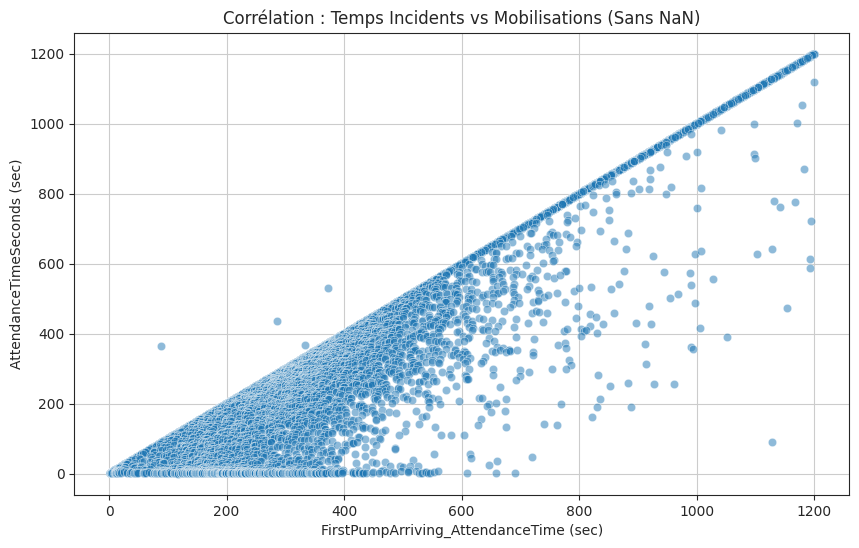

,IncidentNumber,FirstPumpArriving_AttendanceTime,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,Diff
376199,061284-18042024,88.0,2024-04-18 09:53:00,2024-04-18 09:53:00,2024-04-18 09:59:00,12,352,364,-276.0
458677,206918-06122024,373.0,2024-12-06 09:27:00,2024-12-06 09:28:00,2024-12-06 09:36:00,37,494,531,-158.0
440973,175655-16102024,285.0,2024-10-16 17:01:00,2024-10-16 17:02:00,2024-10-16 17:08:00,59,377,436,-151.0
428872,154947-13092024,333.0,2024-09-13 22:24:00,2024-09-13 22:24:00,2024-09-13 22:30:00,23,343,366,-33.0
397502,098296-20062024,370.0,2024-06-20 06:58:00,2024-06-20 07:01:00,2024-06-20 07:05:00,179,191,370,0.0
...,...,...,...,...,...,...,...,...,...
397437,098116-19062024,379.0,2024-06-19 22:24:00,2024-06-19 22:25:00,2024-06-19 22:31:00,61,318,379,0.0
397410,098066-19062024,420.0,2024-06-19 20:46:00,2024-06-19 20:47:00,2024-06-19 20:53:00,62,358,420,0.0
397402,098053-19062024,320.0,2024-06-19 20:32:00,2024-06-19 20:33:00,2024-06-19 20:37:00,57,263,320,0.0
397403,098055-19062024,282.0,2024-06-19 20:34:00,2024-06-19 20:35:00,2024-06-19 20:38:00,79,203,282,0.0


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sélection des colonnes dans Mobilisations
cols_mobilisations = [
    'IncidentNumber',
    'DateAndTimeMobilised',
    'DateAndTimeMobile',
    'DateAndTimeArrived',
    'TurnoutTimeSeconds',
    'TravelTimeSeconds',
    'AttendanceTimeSeconds'
]

# Préparation de la table Mobilisations : exclusion des NaN sur AttendanceTimeSeconds et tri par temps d'arrivée pour identifier le premier engin
df_mob_sub = mobilisation_complet[cols_mobilisations].dropna(subset=['AttendanceTimeSeconds'])
df_mob_first = df_mob_sub.sort_values(by=['IncidentNumber', 'AttendanceTimeSeconds']).drop_duplicates('IncidentNumber')

# Incidents avec un temps de réponse renseigné et non nul
df_inc_sub = incident_complet[
    (incident_complet['FirstPumpArriving_AttendanceTime'].notna()) &
    (incident_complet['FirstPumpArriving_AttendanceTime'] > 0)
][['IncidentNumber', 'FirstPumpArriving_AttendanceTime']]

# Fusion des deux DataFrames
df_correlation = pd.merge(df_inc_sub, df_mob_first, on='IncidentNumber', how='inner')

# Calcul de la corrélation et de la différence
correlation = df_correlation['FirstPumpArriving_AttendanceTime'].corr(df_correlation['AttendanceTimeSeconds'])
df_correlation['Diff'] = df_correlation['FirstPumpArriving_AttendanceTime'] - df_correlation['AttendanceTimeSeconds']

# Tri par différence (du plus petit au plus grand)
df_correlation = df_correlation.sort_values(by='Diff', ascending=True)

# Affichage
print(f"Coefficient de corrélation : {correlation:.4f}")
print(f"Nombre d'incidents après nettoyage : {len(df_correlation)}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_correlation, x='FirstPumpArriving_AttendanceTime', y='AttendanceTimeSeconds', alpha=0.5)
plt.title('Corrélation : Temps Incidents vs Mobilisations (Sans NaN)')
plt.xlabel('FirstPumpArriving_AttendanceTime (sec)')
plt.ylabel('AttendanceTimeSeconds (sec)')
plt.grid(True)
plt.show()

df_correlation.head(100)

In [19]:
df_correlation['Diff'] = df_correlation['FirstPumpArriving_AttendanceTime'] - df_correlation['AttendanceTimeSeconds']
df_correlation_diff = df_correlation[df_correlation['Diff'] != 0]
df_correlation_diff.sort_values(by='Diff', ascending=False)
df_correlation_diff.head(20)
df_correlation_diff.tail(20)

df_correlation.info()
df_correlation_diff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 597486 entries, 376199 to 2980
Data columns (total 9 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   IncidentNumber                    597486 non-null  object        
 1   FirstPumpArriving_AttendanceTime  597486 non-null  float64       
 2   DateAndTimeMobilised              597486 non-null  datetime64[ns]
 3   DateAndTimeMobile                 593824 non-null  datetime64[ns]
 4   DateAndTimeArrived                597486 non-null  datetime64[ns]
 5   TurnoutTimeSeconds                593813 non-null  Int64         
 6   TravelTimeSeconds                 593795 non-null  Int64         
 7   AttendanceTimeSeconds             597486 non-null  Int64         
 8   Diff                              597486 non-null  Float64       
dtypes: Float64(1), Int64(3), datetime64[ns](3), float64(1), object(1)
memory usage: 47.9+ MB
<class 'pandas.co